# Session 14: dense-to-MoE upcycling

**Recorded result:** dense 50M pretraining → 3.514192 validation loss; MoE after 50M continuation → **3.017127**; token-matched dense control → **3.077944**.

This notebook is a portable entry point for the complete Week 14 package. Saved review outputs were executed locally using the reference environment; they are not a Colab training run. Historical metrics are explicitly labeled. Full evaluation and training are optional and disabled initially. The detailed architecture, controls and limitations are in README.md.


In [1]:
from pathlib import Path
import os, sys, subprocess, json

REPOSITORY = "https://github.com/udisinghania/ERAv5.git"
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    REPO_ROOT = Path("/content/ERAv5")
    subprocess.run(["apt-get", "-qq", "update"], check=True)
    subprocess.run(["apt-get", "-qq", "install", "-y", "git-lfs"], check=True)
    subprocess.run(["git", "lfs", "install"], check=True)
    if not REPO_ROOT.exists():
        subprocess.run(["git", "clone", REPOSITORY, str(REPO_ROOT)],
                       env=dict(os.environ, GIT_LFS_SKIP_SMUDGE="1"), check=True)
    PROJECT_ROOT = REPO_ROOT / "Week 14"
    if not (PROJECT_ROOT / "run.py").is_file():
        raise RuntimeError("Week 14 is not present in this checkout. Publish it before using this notebook.")
    subprocess.run(["git", "-C", str(REPO_ROOT), "lfs", "pull",
                    "--include=Week 14/**/*.bin,Week 14/**/*.pt"], check=True)
else:
    candidates = [Path.cwd(), Path.cwd() / "Week 14"]
    PROJECT_ROOT = next((p for p in candidates if (p / "run.py").is_file()), None)
    if PROJECT_ROOT is None:
        raise RuntimeError("Start Jupyter in the extracted Week 14 package directory.")
PROJECT_ROOT = PROJECT_ROOT.resolve()
print("Week 14 package found. Colab:", IN_COLAB)


Week 14 package found. Colab: False


In [2]:
# Install in a fresh Colab runtime. Local review uses the existing environment.
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "torch==2.5.1",
                    "--index-url", "https://download.pytorch.org/whl/cu121"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-r",
                    str(PROJECT_ROOT / "requirements.txt")], check=True)
import torch, numpy
print("Python", sys.version.split()[0], "| torch", torch.__version__, "| numpy", numpy.__version__)
print("CUDA available:", torch.cuda.is_available())
print("BF16:", torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False)


Python 3.12.5 | torch 2.5.1+cu121 | numpy 1.26.4
CUDA available: True
BF16: True


In [3]:
# Change OUTPUT before training if you want a persistent Google Drive folder.
# from google.colab import drive
# drive.mount('/content/drive')
# OUTPUT = Path('/content/drive/MyDrive/ERA/Week14-rerun')
OUTPUT = PROJECT_ROOT / "runs/notebook"
def run(*arguments):
    completed = subprocess.run([sys.executable, "-B", str(PROJECT_ROOT / "run.py"),
                                *arguments, "--output", str(OUTPUT)],
                               cwd=PROJECT_ROOT, text=True, capture_output=True)
    print(completed.stdout)
    if completed.stderr: print(completed.stderr)
    completed.check_returncode()


## Recorded evidence (no training required)

The following table and figures come from the completed original GPU experiments. These results are loaded from files, not recomputed by displaying them.


[
  {
    "stage": "pretraining",
    "model": "dense",
    "loss": 3.5141916687720913,
    "perplexity": 33.588766098981345,
    "validation_targets": 5049456
  },
  {
    "stage": "stage1",
    "model": "moe",
    "loss": 3.417105053807212,
    "perplexity": 30.481046182651554,
    "validation_targets": 5049456
  },
  {
    "stage": "stage1",
    "model": "dense",
    "loss": 3.4272966349501623,
    "perplexity": 30.79328463728143,
    "validation_targets": 5049456
  },
  {
    "stage": "stage2",
    "model": "moe",
    "loss": 3.017127224389041,
    "perplexity": 20.43250927596671,
    "validation_targets": 5049456
  },
  {
    "stage": "stage2",
    "model": "dense",
    "loss": 3.077944414200978,
    "perplexity": 21.713722071075765,
    "validation_targets": 5049456
  }
]



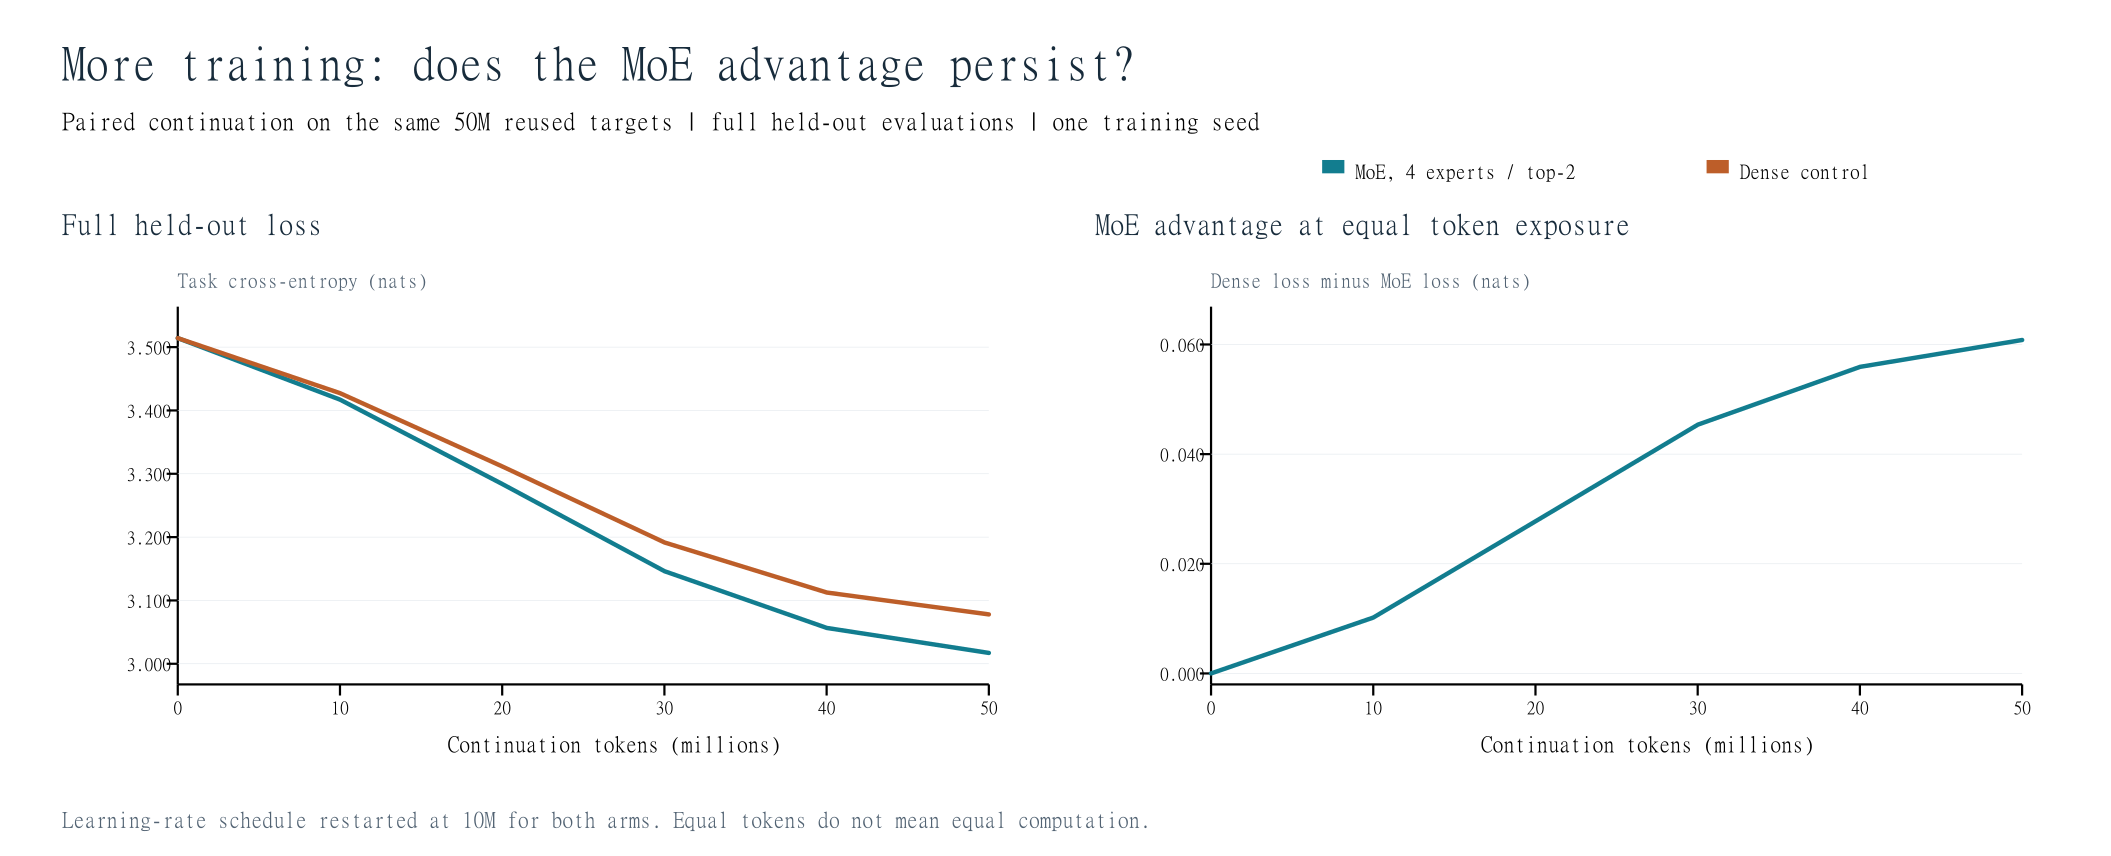

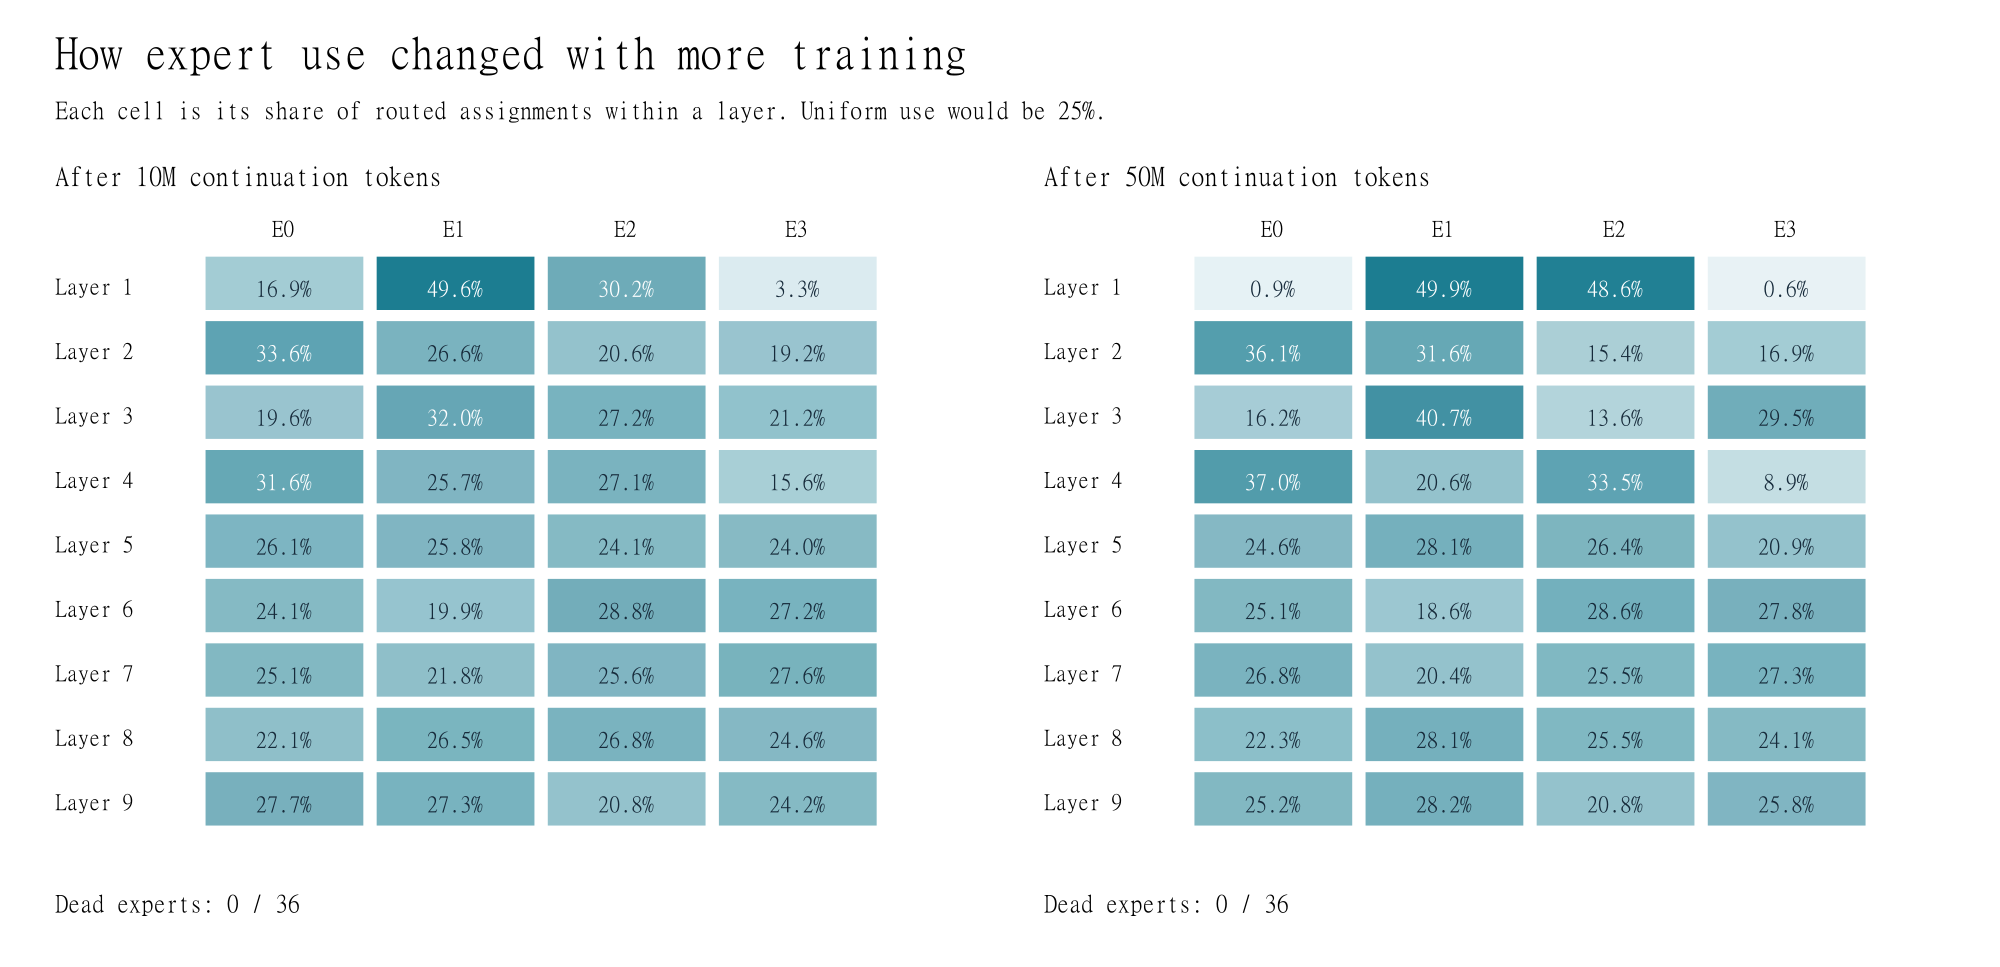

In [4]:
run("summary")
from IPython.display import display, Image
display(Image(filename=str(PROJECT_ROOT / "figures/learning_comparison.png")))
display(Image(filename=str(PROJECT_ROOT / "figures/expert_usage_comparison.png")))


## Verify the clone and load the actual weights

`verify` hashes every packaged file and detects unexpanded LFS pointers. Execute it after cloning. Its output is intentionally not embedded in this notebook because saving new notebook outputs changes the notebook's own checksum. The next cell performs independent CPU semantic tests and loads all three supplied checkpoints.


In [5]:
VERIFY_PACKAGE = False  # Set True after cloning; leave the tracked notebook unchanged for a byte-exact audit.
if VERIFY_PACKAGE:
    run("verify")
else:
    print("Package hash verification available: set VERIFY_PACKAGE = True, or run python run.py verify in a terminal.")
run("tests")
run("check", "--device", "cpu")


Package hash verification available: set VERIFY_PACKAGE = True, or run python run.py verify in a terminal.
{"status": "PASS", "checks": ["All policies preserve the identical-copy function", "Every policy selects two experts per valid token", "Random routing remains causal with fixed RNG", "Restoring learned policy restores outputs"]}

test_causal_document_isolation_and_masking (__main__.MoETests.test_causal_document_isolation_and_masking) ... ok
test_checkpoint_optimizer_roundtrip (__main__.MoETests.test_checkpoint_optimizer_roundtrip) ... ok
test_conversion_and_aggregate_expert_gradient (__main__.MoETests.test_conversion_and_aggregate_expert_gradient) ... ok
test_sparse_dispatch_and_router_task_gradient (__main__.MoETests.test_sparse_dispatch_and_router_task_gradient) ... ok

----------------------------------------------------------------------
Ran 4 tests in 1.037s

OK

{
  "status": "PASS",
  "device": "cpu",
  "checkpoints": [
    {
      "model": "pretrained_dense",
      "parame

## Full held-out evaluation (optional)

Set the switch to True with a BF16-capable CUDA GPU. Each model is evaluated on all 5,049,456 targets. The package's final MoE was reevaluated locally during packaging and reproduced 3.017127224389041 exactly. This is not a new training run.


In [6]:
RUN_FULL_EVALUATION = False
if RUN_FULL_EVALUATION:
    if not torch.cuda.is_available() or not torch.cuda.is_bf16_supported():
        raise RuntimeError("Full evaluation requires a BF16-capable CUDA GPU.")
    for kind in ["pretrained", "dense", "moe"]:
        run("evaluate", "--kind", kind)
else:
    print("Full evaluation not run in this notebook execution.")


Full evaluation not run in this notebook execution.


## Reproduce training (optional)

This executes both complete continuation arms: 10M + 40M targets each. It preserves stage-1 AdamW state for stage 2 and tests the split-sequence boundary. The supplied pretrained dense model is used. To pretrain that model again, use SETUP.md's two pretraining commands, then pass `--prior` pointing to the new pretrain run. All trained artifacts go to OUTPUT; recorded evidence is untouched. A new run may differ numerically across hardware/software.


In [7]:
RUN_TRAINING = False
if RUN_TRAINING:
    if not torch.cuda.is_available() or not torch.cuda.is_bf16_supported():
        raise RuntimeError("Training requires a BF16-capable CUDA GPU with sufficient memory.")
    run("tests")
    run("train", "--phase", "stage1", "--action", "prepare")
    for kind in ["moe", "dense"]:
        run("train", "--phase", "stage1", "--action", "train", "--kind", kind)
    run("train", "--phase", "stage1", "--action", "audit")
    run("train", "--phase", "stage2", "--action", "prepare")
    for kind in ["moe", "dense"]:
        run("train", "--phase", "stage2", "--action", "train", "--kind", kind)
    run("train", "--phase", "stage2", "--action", "diagnostics")
else:
    print("No new training performed. Set RUN_TRAINING = True to start both continuation arms.")


No new training performed. Set RUN_TRAINING = True to start both continuation arms.


For an interrupted training command, rerun that individual command with `--resume`. Do not rerun preparation or completed stages. See SETUP.md. Inspect `OUTPUT/stage2/moe/result.json` and `OUTPUT/stage2/dense/result.json` for new results; the summary cell above always shows the submitted historical evidence.

## Interpretation

Four experts per layer, top-two routing, nine MoE layers, no shared experts and no expert parallelism. The model stores 54,685,440 parameters but activates a theoretical 31,682,304 per token. This is larger than the dense control's active parameter count, so the comparison is **equal exposure, not equal compute**. Router ablations are inference perturbations. One training seed, substantial load imbalance, and weak generation limit the conclusion to demonstrated continued learning in this experiment.
